# Unidad 4 — Notebook 5: Métricas de Clasificación

**Materia:** Métodos de Análisis de Datos 1 (MAD1)  
**Departamento de Matemática — Universidad Nacional del Sur (UNS)**  
**Nombre:**  
**Fecha:**

---

## Glosario de siglas

| Sigla | Significado |
|-------|-------------|
| TP | True Positive (Verdadero Positivo) — predicho positivo, es positivo |
| TN | True Negative (Verdadero Negativo) — predicho negativo, es negativo |
| FP | False Positive (Falso Positivo) — predicho positivo, es negativo |
| FN | False Negative (Falso Negativo) — predicho negativo, es positivo |
| ROC | Receiver Operating Characteristic — curva TPR vs FPR |
| AUC | Area Under the Curve (Área Bajo la Curva ROC) |
| TPR | True Positive Rate = Recall = Sensibilidad |
| FPR | False Positive Rate = 1 - Especificidad |
| PPV | Positive Predictive Value = Precisión |
| PR  | Precision-Recall — curva PPV vs TPR |
| RF  | Random Forest (Bosque Aleatorio) |
| CV  | Cross-Validation (Validación Cruzada) |
| SMOTE | Synthetic Minority Over-sampling Technique — técnica de sobremuestreo sintético |

---

## Objetivos

- Construir e interpretar la matriz de confusión a partir de predicciones dadas.
- Calcular a mano Accuracy, Precisión, Recall, F1-score, TPR y FPR.
- Construir e interpretar curvas ROC (Receiver Operating Characteristic) y PR (Precision-Recall).
- Comprender el impacto de las clases desbalanceadas sobre las métricas.

---

## Parte 1 — Cálculo a mano: matriz de confusión y métricas

Un modelo de clasificación binaria produce las siguientes predicciones sobre 10 pacientes (clase positiva = "Enfermedad presente"):

| Paciente | Clase real | Predicción |
|----------|-----------|------------|
| 1        | Positivo  | Positivo   |
| 2        | Positivo  | Negativo   |
| 3        | Negativo  | Negativo   |
| 4        | Positivo  | Positivo   |
| 5        | Negativo  | Positivo   |
| 6        | Negativo  | Negativo   |
| 7        | Positivo  | Positivo   |
| 8        | Negativo  | Negativo   |
| 9        | Positivo  | Negativo   |
| 10       | Negativo  | Negativo   |

**Ejercicio 1.1** — Completá la matriz de confusión:

|                    | Predicho Positivo | Predicho Negativo |
|--------------------|:-----------------:|:-----------------:|
| **Real Positivo**  | TP = ?            | FN = ?            |
| **Real Negativo**  | FP = ?            | TN = ?            |

De la tabla se obtiene: TP = 3 (1, 4, 7), FN = 2 (2, 9), FP = 1 (5) y TN = 4 (3, 6, 8, 10).

**Ejercicio 1.2** — Con los valores de TP, TN, FP y FN calculados, obtené:

$$\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}$$

$$\text{Precisión} = \frac{TP}{TP + FP}$$

$$\text{Recall} = \text{TPR} = \frac{TP}{TP + FN}$$

$$\text{F1} = \frac{2 \cdot \text{Precisión} \cdot \text{Recall}}{\text{Precisión} + \text{Recall}}$$

$$\text{FPR} = \frac{FP}{FP + TN}$$

Con TP=3, TN=4, FP=1, FN=2:
$$	ext{Accuracy}=rac{TP+TN}{TP+TN+FP+FN}=rac{3+4}{10}=0.70$$
$$	ext{Precisión}=rac{TP}{TP+FP}=rac{3}{4}=0.75$$
$$	ext{Recall}=rac{TP}{TP+FN}=rac{3}{5}=0.60$$
$$F1=2\cdotrac{(0.75)(0.60)}{0.75+0.60}pprox 0.667$$

**Ejercicio 1.3** — En un contexto médico de detección de enfermedad, ¿qué es más grave: un FP o un FN? ¿Qué métrica priorizarías: Precisión o Recall? Justificá.

En un contexto médico suele ser más grave un **FN** (no detectar a un enfermo) que un FP. Por eso priorizaría **Recall**, aunque vigilando también la precisión para no disparar falsos positivos sin control.

**Ejercicio 1.4** — El Accuracy fue alto. Sin embargo, ¿es una métrica suficiente para este problema? ¿Por qué sí o por qué no?

No, accuracy sola no alcanza. Un 0.70 puede parecer aceptable, pero aqu? deja sin detectar 2 de 5 positivos, lo cual es crítico en salud. Conviene complementar con Recall, Precisión, F1 y análisis de umbral.

---

## Parte 2 — Verificación y curva ROC

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_curve, roc_auc_score,
    precision_recall_curve, average_precision_score,
    ConfusionMatrixDisplay
)

y_real = np.array([1, 1, 0, 1, 0, 0, 1, 0, 1, 0])
y_pred = np.array([1, 0, 0, 1, 1, 0, 1, 0, 0, 0])

**Ejercicio 2.1** — Verificá tus cálculos a mano con scikit-learn.

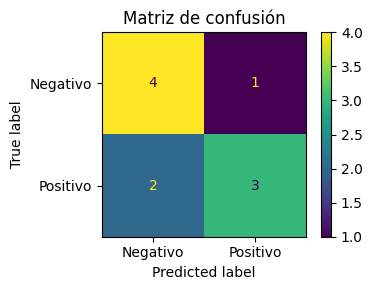

              precision    recall  f1-score   support

    Negativo       0.67      0.80      0.73         5
    Positivo       0.75      0.60      0.67         5

    accuracy                           0.70        10
   macro avg       0.71      0.70      0.70        10
weighted avg       0.71      0.70      0.70        10



In [2]:
cm = confusion_matrix(y_real, y_pred)  # TU CÓDIGO ACÁ

fig, ax = plt.subplots(figsize=(4, 3))
ConfusionMatrixDisplay(cm, display_labels=['Negativo', 'Positivo']).plot(ax=ax)
ax.set_title('Matriz de confusión')
plt.tight_layout()
plt.show()

print(classification_report(y_real, y_pred, target_names=['Negativo', 'Positivo']))

---

## Parte 3 — Curvas ROC y PR sobre un dataset real

In [3]:
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Dataset desbalanceado: 90% clase 0, 10% clase 1
X, y = make_classification(
    n_samples=1000, n_features=10, n_informative=5,
    weights=[0.9, 0.1], random_state=42
)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Proporción clase 1 en test: {y_test.mean():.2%}")

Proporción clase 1 en test: 10.33%


**Ejercicio 3.1** — Entrenás una Regresión Logística (RL) y un RF (Random Forest). Para cada modelo obtenés las probabilidades predichas de la clase positiva.

In [4]:
# Regresión Logística
rl = LogisticRegression(random_state=42)
rl.fit(X_train_sc, y_train)  # TU CÓDIGO ACÁ
prob_rl = rl.predict_proba(X_test_sc)[:, 1]  # probabilidad clase positiva

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_sc, y_train)  # TU CÓDIGO ACÁ
prob_rf = rf.predict_proba(X_test_sc)[:, 1]

**Ejercicio 3.2** — Graficá las curvas ROC (Receiver Operating Characteristic) de ambos modelos en el mismo gráfico. Incluí el AUC (Area Under the Curve) en la leyenda.

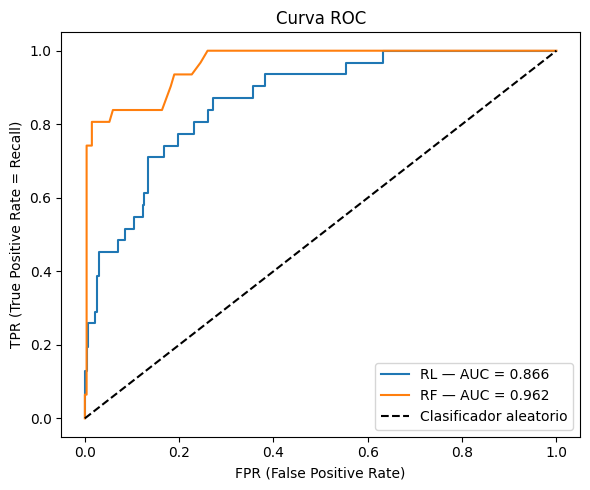

In [5]:
fpr_rl, tpr_rl, _ = roc_curve(y_test, prob_rl)   # TU CÓDIGO ACÁ
fpr_rf, tpr_rf, _ = roc_curve(y_test, prob_rf)   # TU CÓDIGO ACÁ
auc_rl = roc_auc_score(y_test, prob_rl)
auc_rf = roc_auc_score(y_test, prob_rf)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr_rl, tpr_rl, label=f'RL — AUC = {auc_rl:.3f}')
ax.plot(fpr_rf, tpr_rf, label=f'RF — AUC = {auc_rf:.3f}')
ax.plot([0,1],[0,1], 'k--', label='Clasificador aleatorio')
ax.set_xlabel('FPR (False Positive Rate)')
ax.set_ylabel('TPR (True Positive Rate = Recall)')
ax.set_title('Curva ROC')
ax.legend()
plt.tight_layout()
plt.show()

**Ejercicio 3.3** — Graficá las curvas PR (Precision-Recall) de ambos modelos.

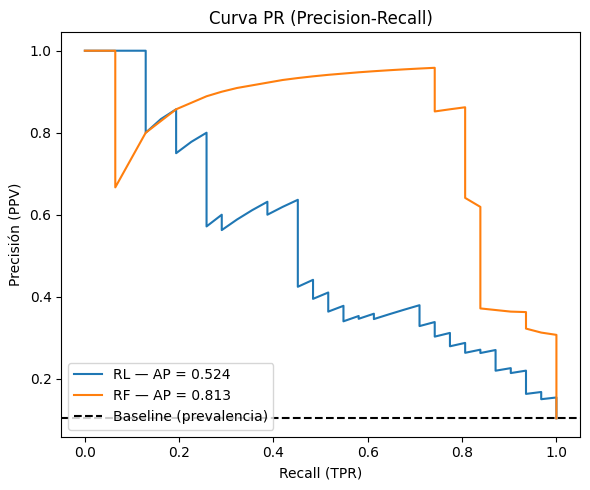

In [6]:
prec_rl, rec_rl, _ = precision_recall_curve(y_test, prob_rl)
prec_rf, rec_rf, _ = precision_recall_curve(y_test, prob_rf)
ap_rl = average_precision_score(y_test, prob_rl)
ap_rf = average_precision_score(y_test, prob_rf)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(rec_rl, prec_rl, label=f'RL — AP = {ap_rl:.3f}')
ax.plot(rec_rf, prec_rf, label=f'RF — AP = {ap_rf:.3f}')
ax.axhline(y=y_test.mean(), linestyle='--', color='k', label='Baseline (prevalencia)')
ax.set_xlabel('Recall (TPR)')
ax.set_ylabel('Precisión (PPV)')
ax.set_title('Curva PR (Precision-Recall)')
ax.legend()
plt.tight_layout()
plt.show()

**Ejercicio 3.4** — ¿Por qué la curva PR es más informativa que la curva ROC cuando las clases están muy desbalanceadas? Usá los resultados del gráfico para justificarlo.

Con clases desbalanceadas, la curva PR suele ser más informativa porque se centra en la clase positiva y muestra directamente el compromiso precisión-recall. La ROC puede verse "buena" aun cuando el desempeño sobre positivos no sea suficiente.

---

## Parte 4 — Umbral de decisión y balance Precisión/Recall

**Ejercicio 4.1** — Por defecto, un clasificador usa umbral = 0.5 para asignar la clase positiva. Probás distintos umbrales y observás cómo varían Precisión y Recall.

In [7]:
from sklearn.metrics import precision_score, recall_score, f1_score

umbrales = [0.1, 0.2, 0.3, 0.5, 0.7, 0.9]

print(f"{'Umbral':>8} {'Precisión':>10} {'Recall':>8} {'F1':>8}")
print('-' * 38)
for u in umbrales:
    y_pred_u = (prob_rf >= u).astype(int)
    p = precision_score(y_test, y_pred_u, zero_division=0)
    r = recall_score(y_test, y_pred_u, zero_division=0)
    f = f1_score(y_test, y_pred_u, zero_division=0)
    print(f"{u:>8.1f} {p:>10.3f} {r:>8.3f} {f:>8.3f}")

  Umbral  Precisión   Recall       F1
--------------------------------------
     0.1      0.362    0.935    0.523
     0.2      0.565    0.839    0.675
     0.3      0.833    0.806    0.820
     0.5      0.957    0.710    0.815
     0.7      0.938    0.484    0.638
     0.9      0.900    0.290    0.439


**Ejercicio 4.2** — Al bajar el umbral de 0.5 a 0.2, ¿qué pasa con el Recall? ¿Y con la Precisión? ¿Por qué existe ese trade-off?

Al bajar umbral de 0.5 a 0.2, sube Recall (0.710 a 0.839) y baja Precisión (0.957 a 0.565). Es el trade-off esperado: detectamos más positivos reales, pero también aumentan los falsos positivos.

**Ejercicio 4.3** — Para el problema médico de detectar una enfermedad grave, ¿qué umbral elegirías y por qué?

Para una enfermedad grave elegiría un umbral más bajo que 0.5 (por ejemplo 0.2?0.3), priorizando no perder enfermos. Después se puede confirmar con pruebas complementarias para filtrar falsos positivos.

---

## Preguntas de reflexión final

1. Un clasificador que siempre predice "Negativo" en un dataset con 90% de negativos tiene Accuracy = 0.90. ¿Es un buen modelo? ¿Qué métricas usarías para demostrarlo?
2. ¿Qué representa el punto $(0, 0)$ y el punto $(1, 1)$ en la curva ROC?
3. Un modelo tiene AUC = 0.95 pero Precisión = 0.30 con umbral 0.5. ¿Cómo interpretás eso? ¿Es contradictorio?

1. No: con desbalance 90/10, predecir siempre "negativo" puede dar accuracy alta sin utilidad clínica. Hay que mirar Recall, Precisión, F1, AUC-PR y matriz de confusión.

2. Si el costo de FN es alto, suele justificarse subir Recall aunque caiga algo la precisión.

3. El umbral final debe definirse con criterio técnico + clínico, según riesgo aceptable y capacidad operativa.